## Make Decision tree

In [86]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder # labelEncoder con text into number
from sklearn.model_selection import train_test_split # split train and testing data
from sklearn.tree import DecisionTreeClassifier # import decision tree algorithm
from sklearn.metrics import accuracy_score # import modal accurcy
from sklearn.tree import plot_tree # draw tree
import matplotlib.pyplot as plt



In [87]:
# Read the CSV file
df = pd.read_csv("Book1.csv" ,sep=",")

# Display first five rows
print(df.head())

   Age  Income  CreditScore Loan_Status
0   22   25000          580    Rejected
1   35   45000          720    Approved
2   28   32000          650    Approved
3   19   18000          500    Rejected
4   42   60000          780    Approved


In [55]:
print(df.info())  # check data set column, null value and data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Age          50 non-null     int64
 1   Income       50 non-null     int64
 2   CreditScore  50 non-null     int64
 3   Loan_Status  50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB
None


In [56]:
encoder = LabelEncoder()

for column in df.columns: # loop throught all the column
    if df[column].dtype == "object": # check colum contain text
        df[column] = encoder.fit_transform(df[column])

In [40]:
X = df.drop("Loan_Status", axis=1)

# Target (Output)
y = df["Loan_Status"]

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
)

In [115]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [116]:
print(df.shape)
print(X_train.shape)
print(X_test.shape)

(50, 4)
(40, 3)
(10, 3)


In [117]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


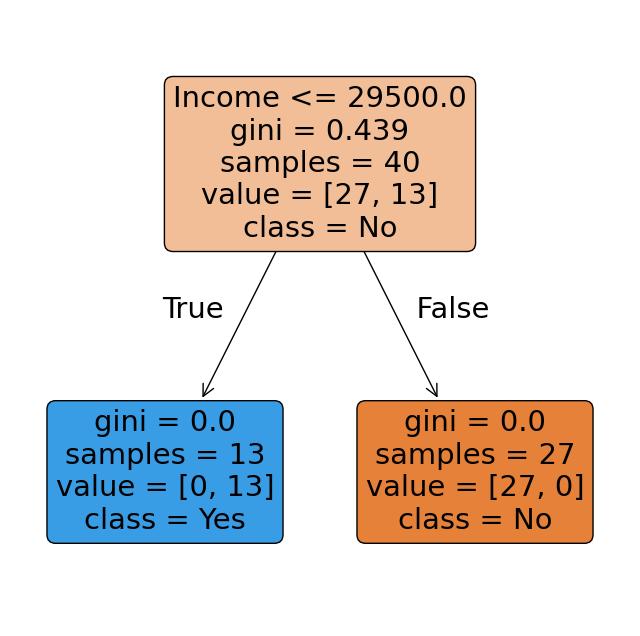

In [120]:
plt.figure(figsize=(8,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True
)

plt.show()